# Weekly Sales Forecasting — Milestone 3: Model Development & Optimization

This notebook implements **Milestone 3** for your weekly sales forecasting project:

1. **Model Selection** – classical time-series (Naive, ETS, ARIMA) and ML models (Random Forest, Gradient Boosting).  
2. **Model Training** – time-based train/test split and time-series cross-validation.  
3. **Model Evaluation** – MAE, MSE, RMSE, R² and residual diagnostics.  
4. **Hyperparameter Tuning** – Grid Search for Random Forest and Gradient Boosting.  
5. **Model Comparison** – compare models and pick the best-performing one.

> **Note:** This notebook assumes your weekly features file is available as  
> `/mnt/data/df_office_weekly_features.csv`.  
> If you are running locally, update the path to where you saved the CSV.


In [55]:
# === Imports ===

import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

# Optional: XGBoost (install via `pip install xgboost` if you don't have it)
try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("Warning: xgboost is not installed. To use XGBoostRegressor, install it with `pip install xgboost`.")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True


In [56]:
# === Load weekly features dataset ===

# Update this path if needed
csv_path = "df_technology_weekly_features.csv"

df = pd.read_csv(csv_path)

print("Shape:", df.shape)
df.head()


Shape: (3323, 29)


,Market,Sub-Category,Year,Week_of_Year,Month,Quarter,Season,Promotion_Flag,Discount,Sales,...,Sales_roll_mean_12,Sales_roll_std_4,Sales_roll_std_12,Quantity_lag_1,Quantity_lag_4,Quantity_lag_12,Quantity_roll_mean_4,Quantity_roll_mean_12,Quantity_roll_std_4,Quantity_roll_std_12
0,APAC,Accessories,2011,17,4,2,Spring,1.0,0.45,659.785500,...,307.570050,253.046208,196.712178,4.0,5.0,10.0,6.50,6.166667,4.509250,4.589184
1,APAC,Accessories,2011,18,5,2,Spring,0.0,0.00,498.390000,...,339.868550,243.849006,193.257041,13.0,3.0,3.0,7.50,6.500000,3.872983,4.482288
2,APAC,Accessories,2011,19,5,2,Spring,0.5,0.25,364.480581,...,333.501932,205.113348,190.870531,7.0,6.0,4.0,10.50,7.666667,6.244998,5.482755
3,APAC,Accessories,2011,21,5,2,Autumn,0.5,0.05,1218.300000,...,413.539432,375.322271,316.374281,18.0,4.0,2.0,14.25,9.083333,5.500000,6.052172
4,APAC,Accessories,2011,22,6,2,Spring,0.4,0.04,1233.352581,...,494.116314,461.929366,390.053650,19.0,13.0,3.0,16.75,10.750000,6.849574,6.916712


In [57]:
# === Basic data inspection ===

df.info()
df.describe(include="all").T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3323 entries, 0 to 3322
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Market                 3323 non-null   object 
 1   Sub-Category           3323 non-null   object 
 2   Year                   3323 non-null   int64  
 3   Week_of_Year           3323 non-null   int64  
 4   Month                  3323 non-null   int64  
 5   Quarter                3323 non-null   int64  
 6   Season                 3323 non-null   object 
 7   Promotion_Flag         3323 non-null   float64
 8   Discount               3323 non-null   float64
 9   Sales                  3323 non-null   float64
 10  Quantity               3323 non-null   int64  
 11  week_sin               3323 non-null   float64
 12  week_cos               3323 non-null   float64
 13  year_week              3323 non-null   object 
 14  year_week_date         3323 non-null   object 
 15  Sale

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Market,3323,7,APAC,692,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sub-Category,3323,4,Phones,968,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,3323.0,NaN,NaN,NaN,2012.742401,1.051574,2011.0,2012.0,2013.0,2014.0,2014.0
Week_of_Year,3323.0,NaN,NaN,NaN,29.24827,14.653885,1.0,18.0,31.0,42.0,52.0
Month,3323.0,NaN,NaN,NaN,7.158291,3.353125,1.0,5.0,7.0,10.0,12.0
Quarter,3323.0,NaN,NaN,NaN,2.699368,1.084157,1.0,2.0,3.0,4.0,4.0
Season,3323,4,Autumn,1015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Promotion_Flag,3323.0,NaN,NaN,NaN,0.364786,0.397538,0.0,0.0,0.25,0.666667,1.0
Discount,3323.0,NaN,NaN,NaN,0.082465,0.110122,0.0,0.0,0.033333,0.135333,0.5
Sales,3323.0,NaN,NaN,NaN,645.339299,547.674577,10.384,246.490581,492.981162,913.068941,5042.028965


In [58]:
# === Configuration: column names ===
# Adjust these if your file uses different names.

DATE_COL = "year_week_date"     # weekly date or week-start date
TARGET_COL = "Sales"            # weekly sales
PROMO_COL = "Promotion_Flag"    # 0/1 promotion flag
DISCOUNT_COL = "Discount"       # discount level
QTY_COL = "Quantity"            # quantity sold

# Convert date column to datetime
df[DATE_COL] = pd.to_datetime(df[DATE_COL])

# Aggregate to weekly level (if already weekly, this will just group identical weeks)
weekly = (
    df.groupby(DATE_COL)
      .agg({
          TARGET_COL: "sum",
          PROMO_COL: "mean",
          DISCOUNT_COL: "mean",
          QTY_COL: "sum"
      })
      .reset_index()
      .sort_values(DATE_COL)
)

weekly = weekly.rename(columns={
    DATE_COL: "week_date",
    TARGET_COL: "Sales",
    PROMO_COL: "Promotion_Flag",
    DISCOUNT_COL: "Discount",
    QTY_COL: "Quantity"
})

print("Weekly shape:", weekly.shape)
weekly.head()


Weekly shape: (195, 5)


,week_date,Sales,Promotion_Flag,Discount,Quantity
0,2011-04-04,246.490581,0.000000,0.000000,5
1,2011-04-11,1093.995162,0.500000,0.045000,17
2,2011-04-18,1265.712000,0.750000,0.266667,19
3,2011-04-25,2186.202081,0.479167,0.170833,45
4,2011-05-02,1653.962481,0.375000,0.121250,19


In [59]:
# === Feature engineering for weekly time series ===

weekly["Year"] = weekly["week_date"].dt.isocalendar().year.astype(int)
weekly["Week_of_Year"] = weekly["week_date"].dt.isocalendar().week.astype(int)
weekly["Month"] = weekly["week_date"].dt.month
weekly["Quarter"] = weekly["week_date"].dt.quarter

# Cyclical encoding for seasonal weekly pattern
weekly["week_sin"] = np.sin(2 * math.pi * weekly["Week_of_Year"] / 52)
weekly["week_cos"] = np.cos(2 * math.pi * weekly["Week_of_Year"] / 52)

# Lag features and rolling means of Sales
for lag in [1, 2, 4, 12]:
    weekly[f"lag_{lag}"] = weekly["Sales"].shift(lag)

weekly["roll_mean_4"] = weekly["Sales"].rolling(4).mean()
weekly["roll_mean_12"] = weekly["Sales"].rolling(12).mean()

# Drop rows with NaNs introduced by lags/rolling
data = weekly.dropna().reset_index(drop=True)

print("Data for modeling:", data.shape)
data.head()


Data for modeling: (183, 17)


,week_date,Sales,Promotion_Flag,Discount,Quantity,Year,Week_of_Year,Month,Quarter,week_sin,week_cos,lag_1,lag_2,lag_4,lag_12,roll_mean_4,roll_mean_12
0,2011-06-27,6394.615262,0.357143,0.072738,73,2011,26,6,2,-3.216245e-16,-1.000000,10169.656673,5595.402747,8761.926431,246.490581,7102.894354,4379.575506
1,2011-07-04,3976.479605,0.590909,0.172000,57,2011,27,7,3,-1.205367e-01,-0.992709,6394.615262,10169.656673,6251.902732,1093.995162,6534.038572,4619.782543
2,2011-07-11,5655.307205,0.527211,0.115143,88,2011,28,7,3,-2.393157e-01,-0.970942,3976.479605,6394.615262,5595.402747,1265.712000,6549.014686,4985.582143
3,2011-07-18,5609.562588,0.410256,0.109513,99,2011,29,7,3,-3.546049e-01,-0.935016,5655.307205,3976.479605,10169.656673,2186.202081,5408.991165,5270.862186
4,2011-07-25,6570.284288,0.500000,0.102013,91,2011,30,7,3,-4.647232e-01,-0.885456,5609.562588,5655.307205,6394.615262,1653.962481,5452.908422,5680.555669


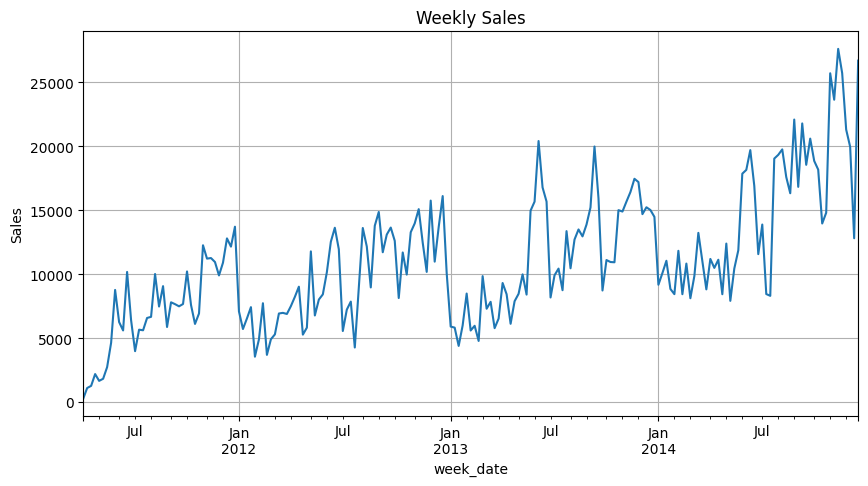

In [60]:
# === Visualize weekly sales ===

ax = weekly.set_index("week_date")["Sales"].plot()
ax.set_title("Weekly Sales")
ax.set_ylabel("Sales")
plt.show()


In [61]:
# === Feature matrix X and target vector y ===

feature_cols = [
    "Promotion_Flag", "Discount",
    "Year", "Week_of_Year", "Month", "Quarter",
    "week_sin", "week_cos",
    "lag_1", "lag_2", "lag_4", "lag_12",
    "roll_mean_4", "roll_mean_12"
]

X = data[feature_cols]
y = data["Sales"]

# Time-based train/test split (80% train, 20% test)
n = len(data)
train_size = int(0.8 * n)

X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]
dates_train = data["week_date"].iloc[:train_size]
dates_test = data["week_date"].iloc[train_size:]

print("Train size:", X_train.shape, "Test size:", X_test.shape)


Train size: (146, 14) Test size: (37, 14)


In [62]:
# === Evaluation helpers ===

def eval_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2 , "MAPE":mape}

def print_metrics(name, metrics):
    print(f"{name}")
    print("-" * len(name))
    for k, v in metrics.items():
        print(f"{k}: {v:,.2f}")
    print()


In [63]:
# === Baseline and classical time-series models ===

# Dictionary to collect all evaluation metrics
results = {}

# Dictionary to keep test-set predictions for each model
preds_test = {}

# 1) Naive last-week forecast
y_all = y.reset_index(drop=True)
naive_series = y_all.shift(1)
naive_preds = naive_series.iloc[train_size:].values

metrics_naive = eval_metrics(y_test, naive_preds)
print_metrics("Naive (Last Week)", metrics_naive)
results["Naive"] = metrics_naive
preds_test["Naive"] = naive_preds

# 2) Exponential Smoothing (Holt-Winters)
train_sales = y_train.astype(float)

ets_model = ExponentialSmoothing(
    train_sales,
    trend="add",
    seasonal="add",
    seasonal_periods=52
)

ets_fit = ets_model.fit(optimized=True)
ets_forecast = ets_fit.forecast(len(y_test))

metrics_ets = eval_metrics(y_test, ets_forecast)
print_metrics("ETS (Holt-Winters)", metrics_ets)
results["ETS"] = metrics_ets
preds_test["ETS"] = ets_forecast

# 3) ARIMA (simple example; consider tuning order for your data)
# Using order (1,1,1) as a simple starting point
arima_model = ARIMA(train_sales, order=(1, 1, 1))
arima_fit = arima_model.fit()
arima_forecast = arima_fit.forecast(steps=len(y_test))

metrics_arima = eval_metrics(y_test, arima_forecast)
print_metrics("ARIMA(1,1,1)", metrics_arima)
results["ARIMA(1,1,1)"] = metrics_arima
preds_test["ARIMA(1,1,1)"] = arima_forecast


Naive (Last Week)
-----------------
MAE: 3,500.30
MSE: 21,975,225.98
RMSE: 4,687.77
R2: 0.24
MAPE: 0.22

ETS (Holt-Winters)
------------------
MAE: 3,303.98
MSE: 16,299,974.96
RMSE: 4,037.32
R2: 0.44
MAPE: 0.20

ARIMA(1,1,1)
------------
MAE: 6,258.02
MSE: 58,149,745.63
RMSE: 7,625.60
R2: -1.01
MAPE: 0.33



In [64]:
# === Machine Learning models with Pipelines + TimeSeries cross‑validation ===

# TimeSeriesSplit for cross-validation (keeps the time order)
tscv = TimeSeriesSplit(n_splits=4)

best_ml_models = {}

# Helper function to train + evaluate a model (with optional GridSearch)
def run_model_with_cv(name, pipeline, param_grid=None):
    """Fit a pipeline using TimeSeriesSplit CV and evaluate on the hold‑out test set."""
    if param_grid is not None and len(param_grid) > 0:
        gs = GridSearchCV(
            pipeline,
            param_grid,
            cv=tscv,
            scoring="neg_mean_absolute_error",
            n_jobs=-1
        )
        gs.fit(X_train, y_train)
        best_model = gs.best_estimator_
        print(f"{name} - Best params: {gs.best_params_}")
        print(f"{name} - Best CV MAE: {-gs.best_score_:.2f}\n")
    else:
        best_model = pipeline
        best_model.fit(X_train, y_train)

    # Evaluate on test set
    y_pred = best_model.predict(X_test)
    preds_test[name] = y_pred
    metrics = eval_metrics(y_test, y_pred)
    print_metrics(name, metrics)
    results[name] = metrics
    best_ml_models[name] = best_model



# 1) Decision Tree Regressor
pipe_dt = Pipeline([
    ("model", DecisionTreeRegressor(random_state=42))
])

param_dt = {
    "model__max_depth": [3, 5, 7, None],
    "model__min_samples_leaf": [1, 5, 10]
}

run_model_with_cv("Decision Tree", pipe_dt, param_dt)

# 2) Random Forest Regressor
pipe_rf = Pipeline([
    ("model", RandomForestRegressor(random_state=42))
])

param_rf = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [5, None],
    "model__min_samples_leaf": [1, 5]
}

run_model_with_cv("Random Forest", pipe_rf, param_rf)

# 3) Gradient Boosting Regressor
pipe_gbr = Pipeline([
    ("model", GradientBoostingRegressor(random_state=42))
])

param_gbr = {
    "model__n_estimators": [200, 300],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3]
}

run_model_with_cv("Gradient Boosting", pipe_gbr, param_gbr)

# 4) XGBoost Regressor (if available)
if XGB_AVAILABLE:
    pipe_xgb = Pipeline([
        ("model", XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            n_estimators=300,
            n_jobs=-1
        ))
    ])               

    param_xgb = {
        "model__max_depth": [3, 4, 5],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.8, 1.0]
    }

    run_model_with_cv("XGBoost", pipe_xgb, param_xgb)
else:
    print("Skipping XGBoost: XGBRegressor is not available.")


Decision Tree - Best params: {'model__max_depth': 5, 'model__min_samples_leaf': 10}
Decision Tree - Best CV MAE: 2187.88

Decision Tree
-------------
MAE: 4,297.22
MSE: 32,612,054.75
RMSE: 5,710.70
R2: -0.13
MAPE: 0.23

Random Forest - Best params: {'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
Random Forest - Best CV MAE: 1971.42

Random Forest
-------------
MAE: 3,851.67
MSE: 25,527,814.92
RMSE: 5,052.51
R2: 0.12
MAPE: 0.21

Gradient Boosting - Best params: {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 200}
Gradient Boosting - Best CV MAE: 2082.89

Gradient Boosting
-----------------
MAE: 4,869.04
MSE: 38,902,323.89
RMSE: 6,237.17
R2: -0.35
MAPE: 0.26

XGBoost - Best params: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__subsample': 0.8}
XGBoost - Best CV MAE: 1960.22

XGBoost
-------
MAE: 4,376.83
MSE: 33,759,076.20
RMSE: 5,810.26
R2: -0.17
MAPE: 0.23



In [65]:
# === Compare all models ===

results_df = (
    pd.DataFrame(results)
      .T[["MAE", "RMSE", "R2","MAPE"]]
      .sort_values("RMSE")
)

results_df


,MAE,RMSE,R2,MAPE
ETS,3303.984266,4037.322746,0.435596,0.196926
Naive,3500.302067,4687.774097,0.239085,0.216873
Random Forest,3851.671644,5052.505806,0.116073,0.206426
Decision Tree,4297.218600,5710.696520,-0.129227,0.229704
XGBoost,4376.833480,5810.256122,-0.168943,0.227518
Gradient Boosting,4869.037612,6237.172748,-0.347034,0.259657
"ARIMA(1,1,1)",6258.021454,7625.598050,-1.013496,0.331962


=== Plotting for model: Naive ===


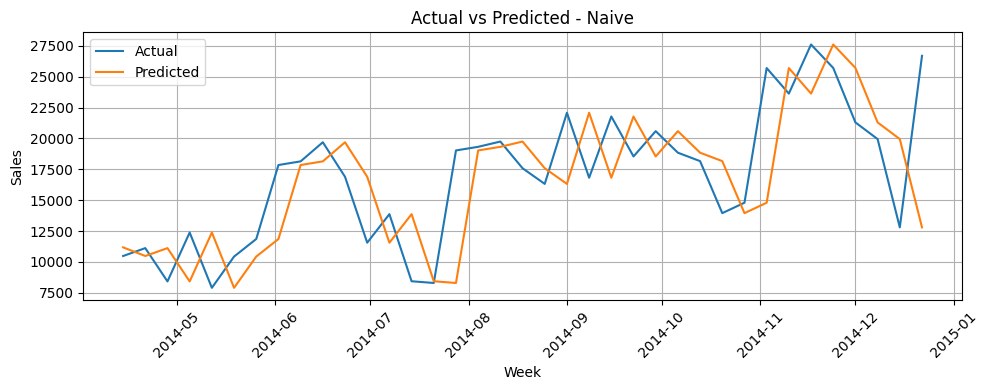

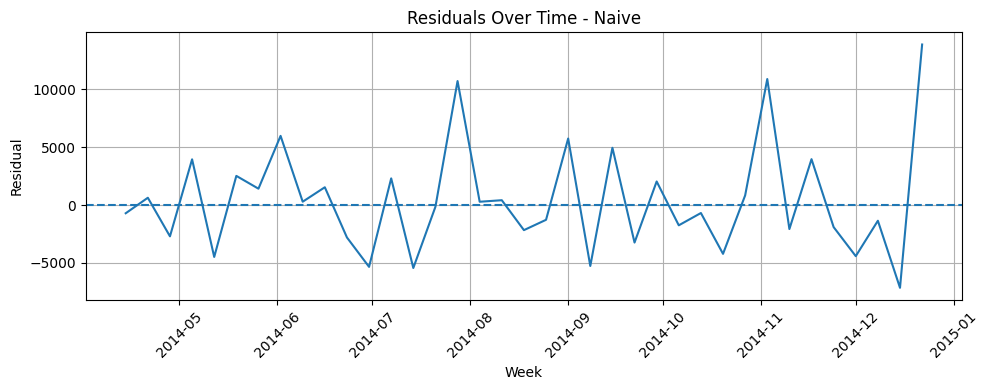

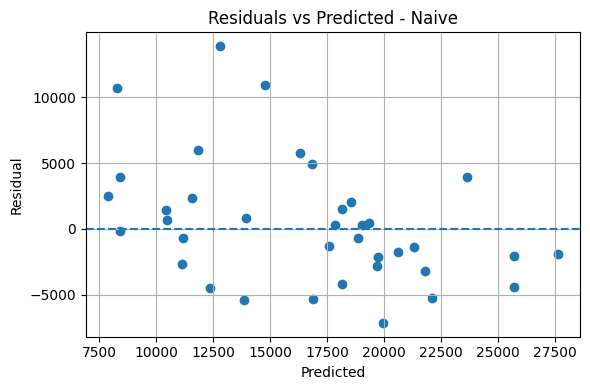

=== Plotting for model: ETS ===


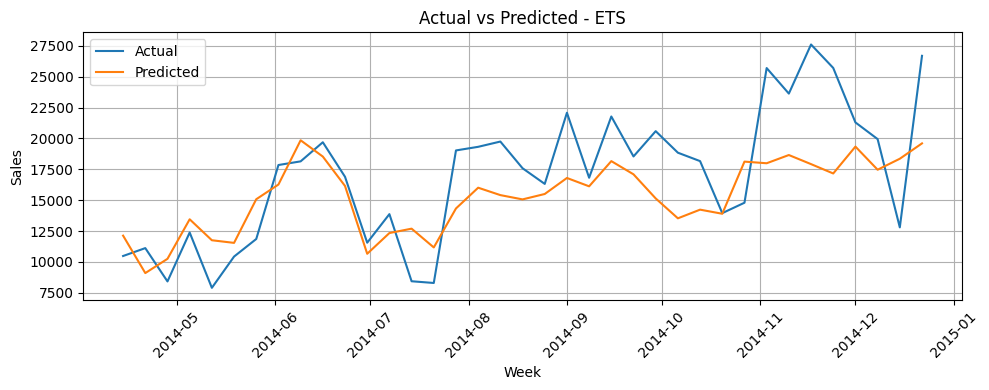

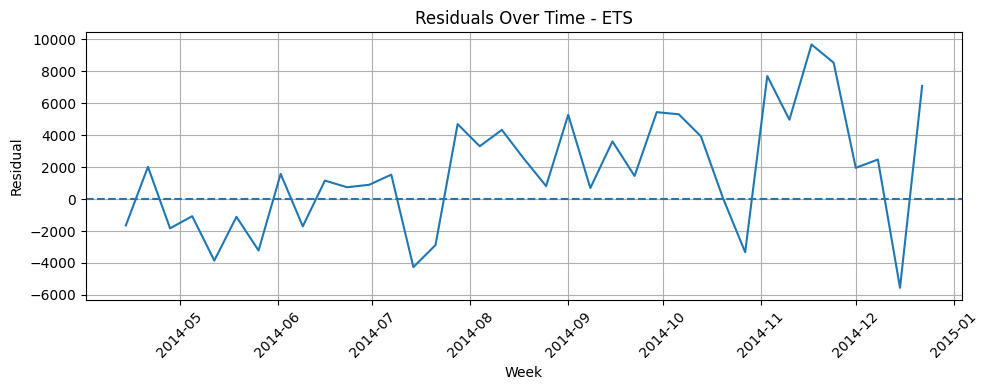

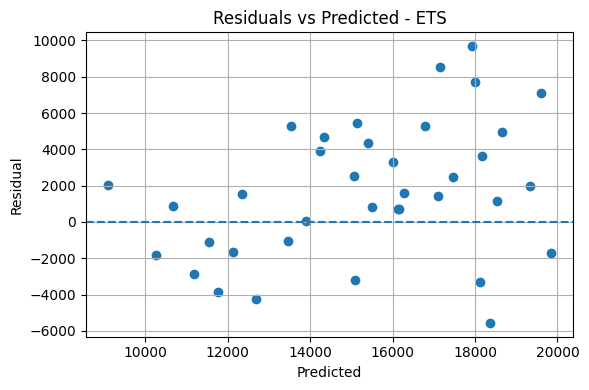

=== Plotting for model: ARIMA(1,1,1) ===


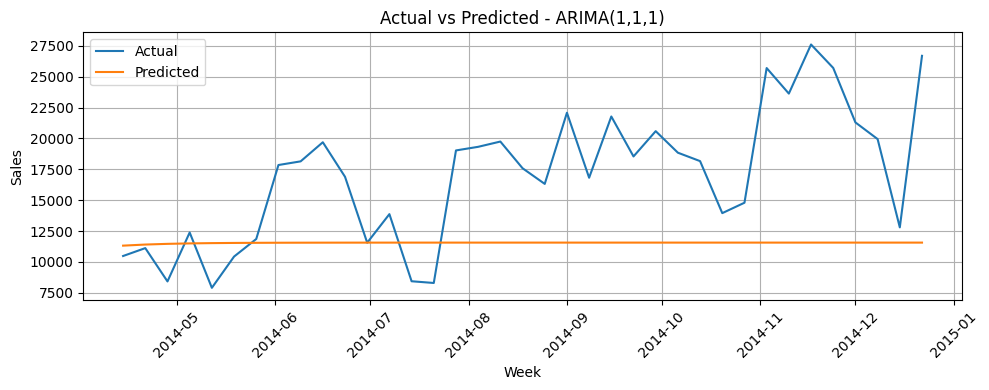

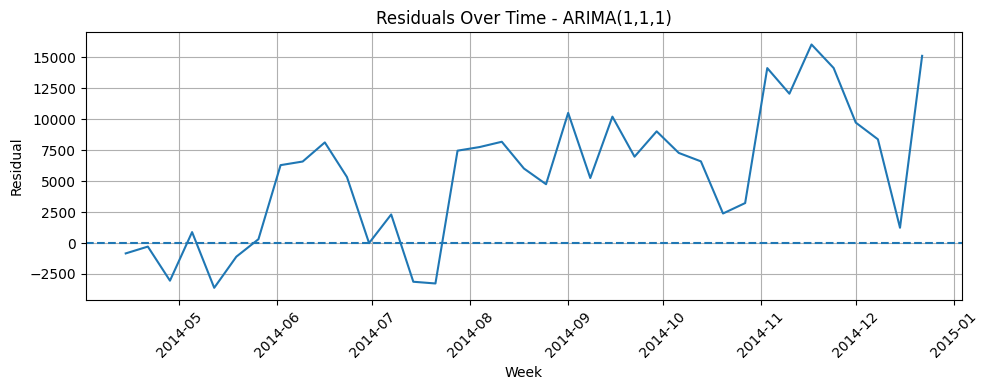

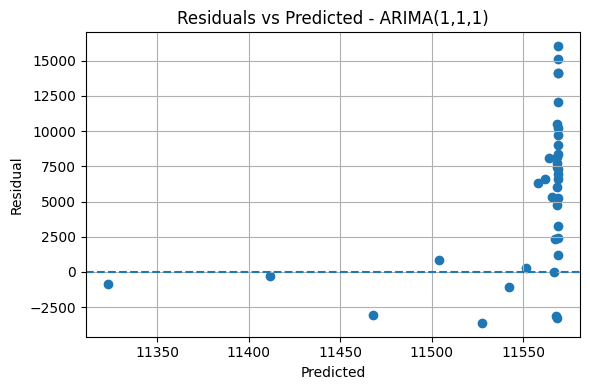

=== Plotting for model: Decision Tree ===


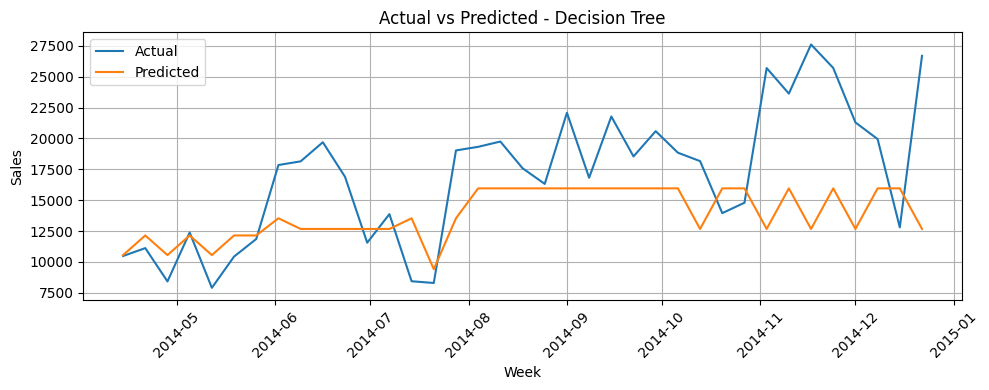

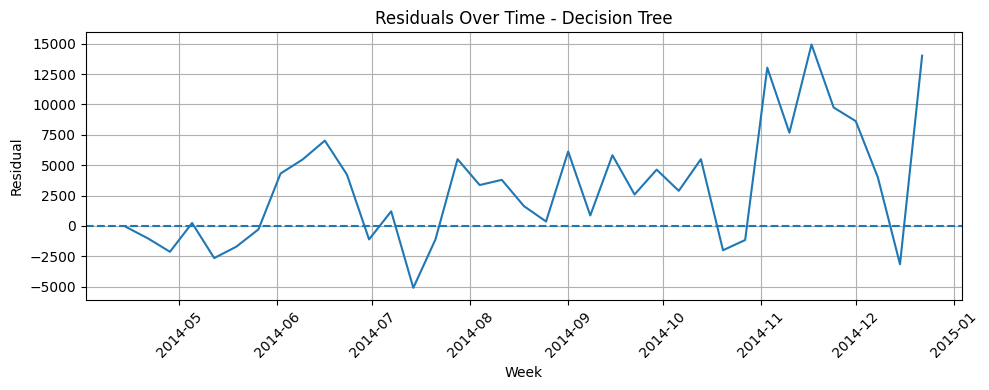

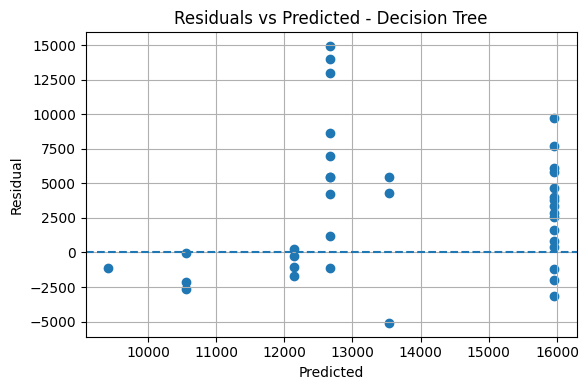

=== Plotting for model: Random Forest ===


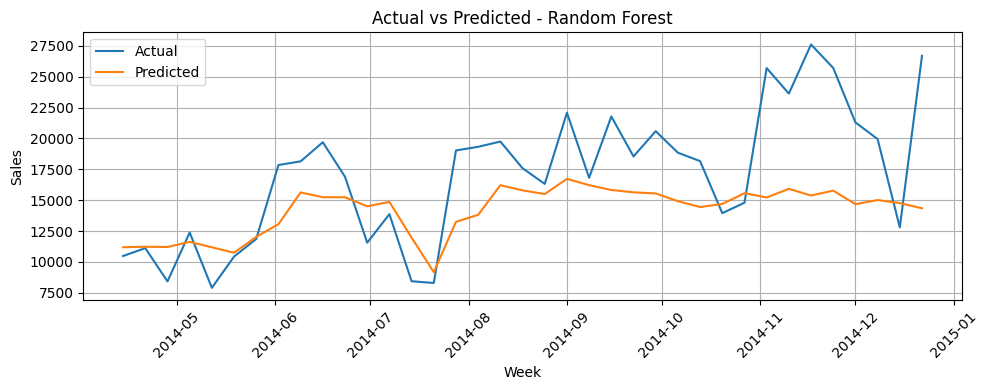

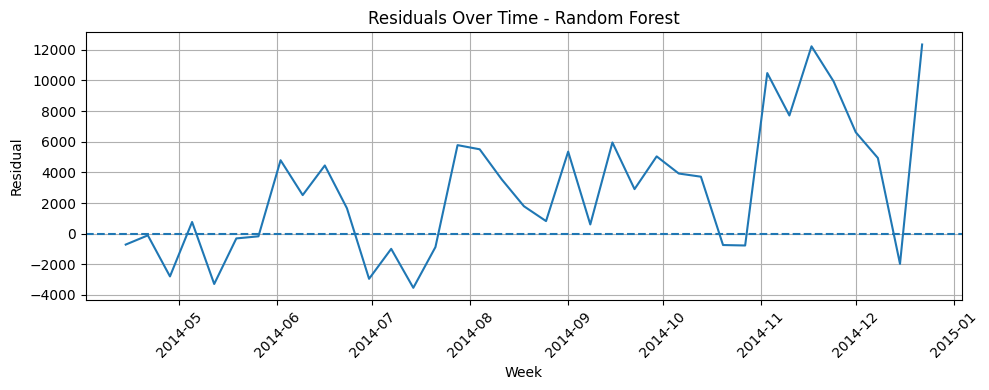

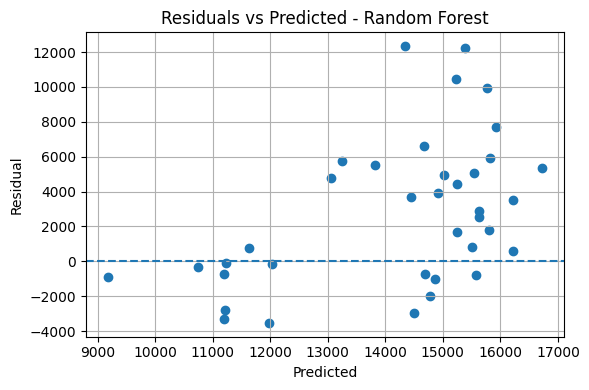

=== Plotting for model: Gradient Boosting ===


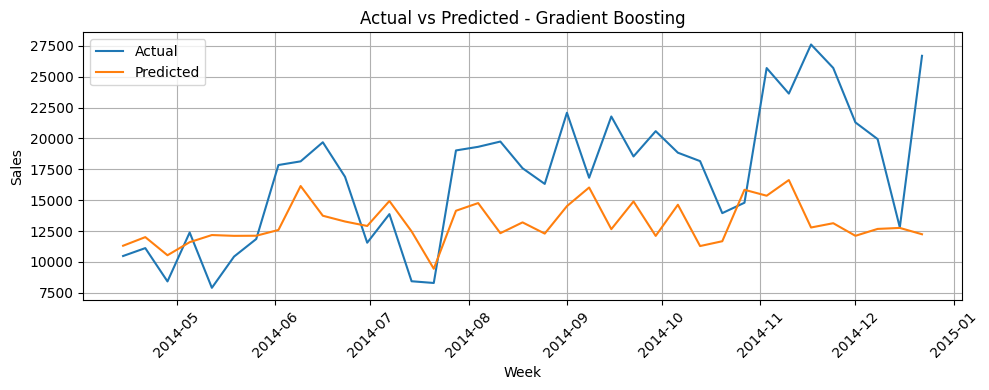

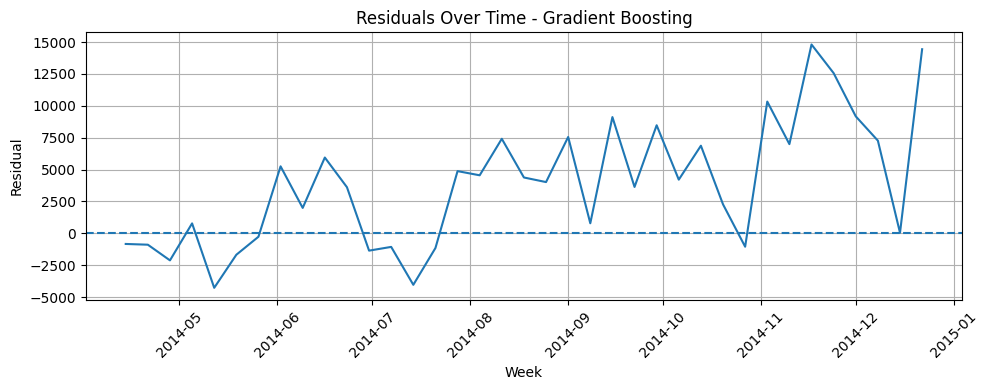

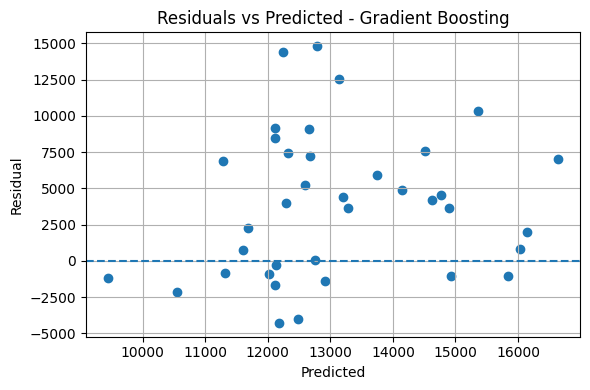

=== Plotting for model: XGBoost ===


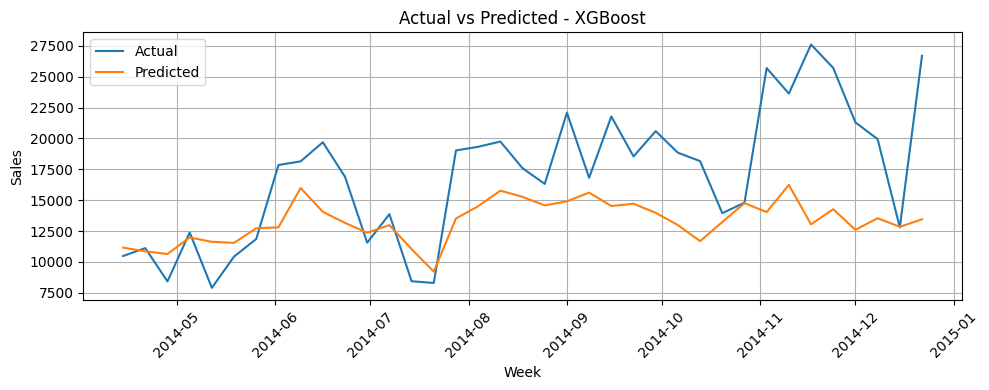

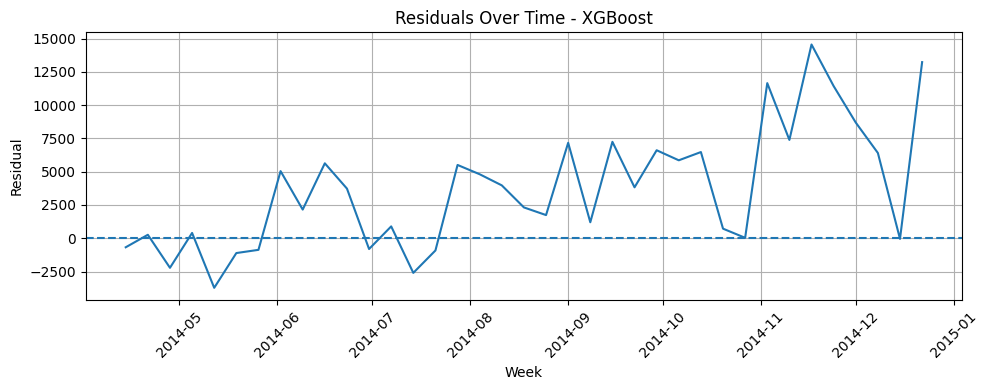

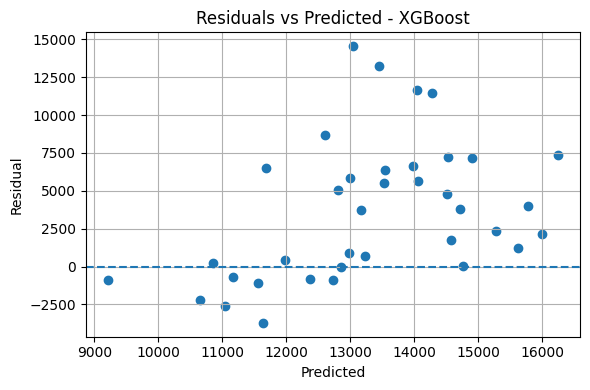

In [66]:
# === Plot Actual vs Predicted and Residuals FOR ALL MODELS ===

for model_name, model_preds in preds_test.items():
    print(f"=== Plotting for model: {model_name} ===")

    residuals = y_test - model_preds

    # Actual vs Predicted
    plt.figure(figsize=(10, 4))
    plt.plot(dates_test, y_test.values, label="Actual")
    plt.plot(dates_test, model_preds, label="Predicted")
    plt.title(f"Actual vs Predicted - {model_name}")
    plt.xlabel("Week")
    plt.ylabel("Sales")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Residuals over time
    plt.figure(figsize=(10, 4))
    plt.plot(dates_test, residuals)
    plt.axhline(0, linestyle="--")
    plt.title(f"Residuals Over Time - {model_name}")
    plt.xlabel("Week")
    plt.ylabel("Residual")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Residuals vs Predicted
    plt.figure(figsize=(6, 4))
    plt.scatter(model_preds, residuals)
    plt.axhline(0, linestyle="--")
    plt.title(f"Residuals vs Predicted - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Residual")
    plt.tight_layout()
    plt.show()


In [67]:
df['year_week_date'] = pd.to_datetime(df['year_week_date'])
df['year_week_date'].describe()

count                             3323
mean     2013-04-13 23:19:41.944026368
min                2011-04-04 00:00:00
25%                2012-06-04 00:00:00
50%                2013-05-06 00:00:00
75%                2014-03-10 00:00:00
max                2014-12-22 00:00:00
Name: year_week_date, dtype: object

In [68]:
import joblib

In [69]:
best_model = max(results, key=lambda k: results[k]["R2"])
print("Best model by R2:", best_name)


Best model by R2: Gradient Boosting


In [70]:
joblib.dump(best_model, "best_technology_sales_model.joblib")
print("Model saved successfully!")

Model saved successfully!
